# estime_msrp 피쳐 추가 스케일링 진행

- Strategy: estime_msrp 스케일링 추가

## Step 11. 수치형 스케일링

In [ ]:
# 스케일링 적용 전 X_train 원본 복사본 저장
# StandardScaler는 X_train을 직접 변환(in-place)하기 때문에,
# 스케일링 이전의 원본 값이 필요한 시각화(e.g., estimate_msrp Before/After 비교)에서
# X_train_raw를 참조할 수 있도록 미리 복사해둠.
X_train_raw = X_train.copy()

print(f"X_train_raw 저장 완료: {X_train_raw.shape}")
print(f"estimate_msrp 원본 통계 - 평균: {X_train_raw['estimate_msrp'].mean():.0f}, 표준편차: {X_train_raw['estimate_msrp'].std():.0f}")

In [ ]:
# 11. 수치형 변수 StandardScaler 적용

# estimate_msrp: 우측 꼬리 분포 → 정규분포에 가깝게 만들기 위해 log1p 변환 먼저 적용
X_train['estimate_msrp'] = np.log1p(X_train['estimate_msrp'])
X_test['estimate_msrp'] = np.log1p(X_test['estimate_msrp'])

# log1p 변환 후, 스케일링 전 상태 저장 (Section 5·6 시각화용)
X_train_log1p = X_train.copy()

scaler = StandardScaler()

# 스케일링 대상 피처 지정
num_cols = ['odometer', 'vehicle_age', 'model_encoded', 'estimate_msrp']

# X_train에는 fit_transform(기준점 잡기+변환), X_test에는 transform(변환)만 적용
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("모든 전처리 파이프라인 완벽 종료! 모델링 준비 끝")
print("\n[최종 X_train 데이터 프리뷰]")
display(X_train.head(3))

## 중간 데이터셋 뽑기

In [14]:
# vehicles_v2 = 'vehicles_v2.csv'
# df_step4.to_csv(vehicles_v2, index=False)

# 전처리 완료 데이터 EDA (사후 검증 시각화)

In [ ]:
# 시각화 테마 설정
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['axes.unicode_minus'] = False

# 시각화를 위해 X_train과 y_train_log를 임시로 병합 (분석용)
df_eda = X_train.copy()
df_eda['price_log'] = y_train_log

print("EDA용 통합 데이터프레임 준비 완료")

EDA용 통합 데이터프레임 준비 완료


## 1. 로그 변환된 타겟 변수 분포 확인

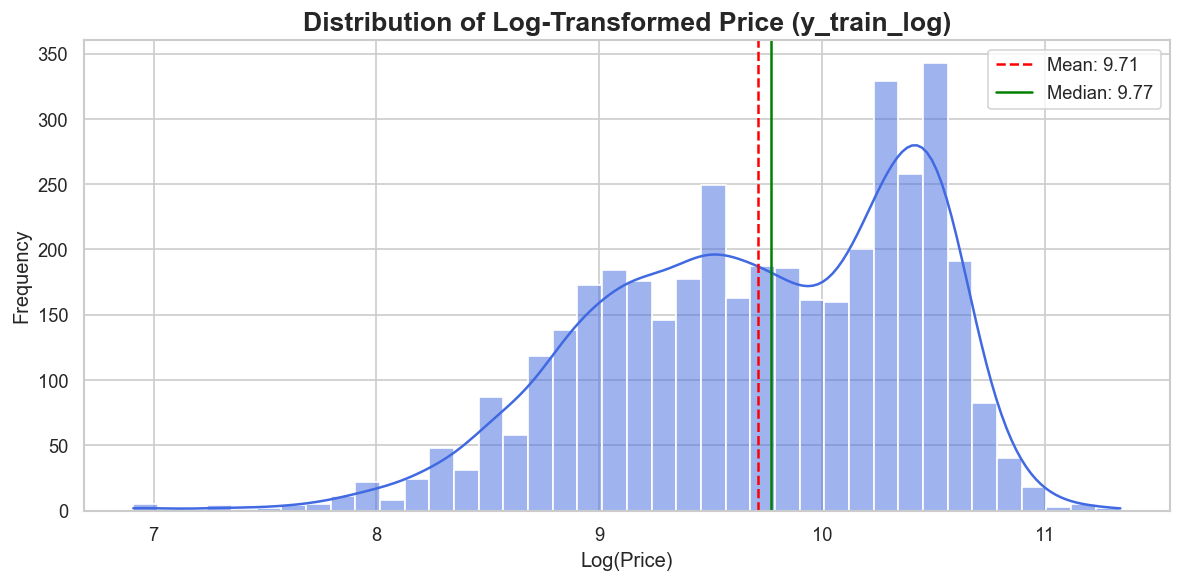

In [1]:
# 1. 정답지(Target) 분포 검증

plt.figure(figsize=(10, 5))
sns.histplot(df_eda['price_log'], bins=40, kde=True, color='royalblue')
plt.title("Distribution of Log-Transformed Price (y_train_log)", fontsize=16, fontweight='bold')
plt.xlabel("Log(Price)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# 평균과 중앙값 표시
plt.axvline(df_eda['price_log'].mean(), color='red', linestyle='--', label=f"Mean: {df_eda['price_log'].mean():.2f}")
plt.axvline(df_eda['price_log'].median(), color='green', linestyle='-', label=f"Median: {df_eda['price_log'].median():.2f}")

plt.legend()
plt.tight_layout()
plt.show()

#### Distribution of Log-Transformed Price (y_train_log) 그래프 해석

**기대 이유(효과)**  
보통의 중고차 가격 그래프는 중간 가격대가 가장 많고 일부의 고가 차량으로 인해 오른쪽 꼬리가 긴 형태의 그래프가 나옴.  
이러한 문제를 로그 변환을 통해 분포를 더 안정적으로 만들고 모델 학습 성능을 개선하고자 했음.

---

**결과 해석**  
분포가 한쪽으로 심하게 치우치지 않고 비교적 완만해짐.  

평균 = 9.71, 중앙값 = 9.77로 둘이 매우 가까움.  
→ 데이터가 극단적으로 치우쳐 있지 않다.  
→ 로그 변환이 왜도를 줄이는 데 효과적이었다는 해석이 가능해짐.

두 개의 봉우리는 저가 차량 그룹과 고가 차량 그룹이 어느 정도 나뉘어져있을 가능성이 있음.

## 2. StandardScaler 적용 결과 확인

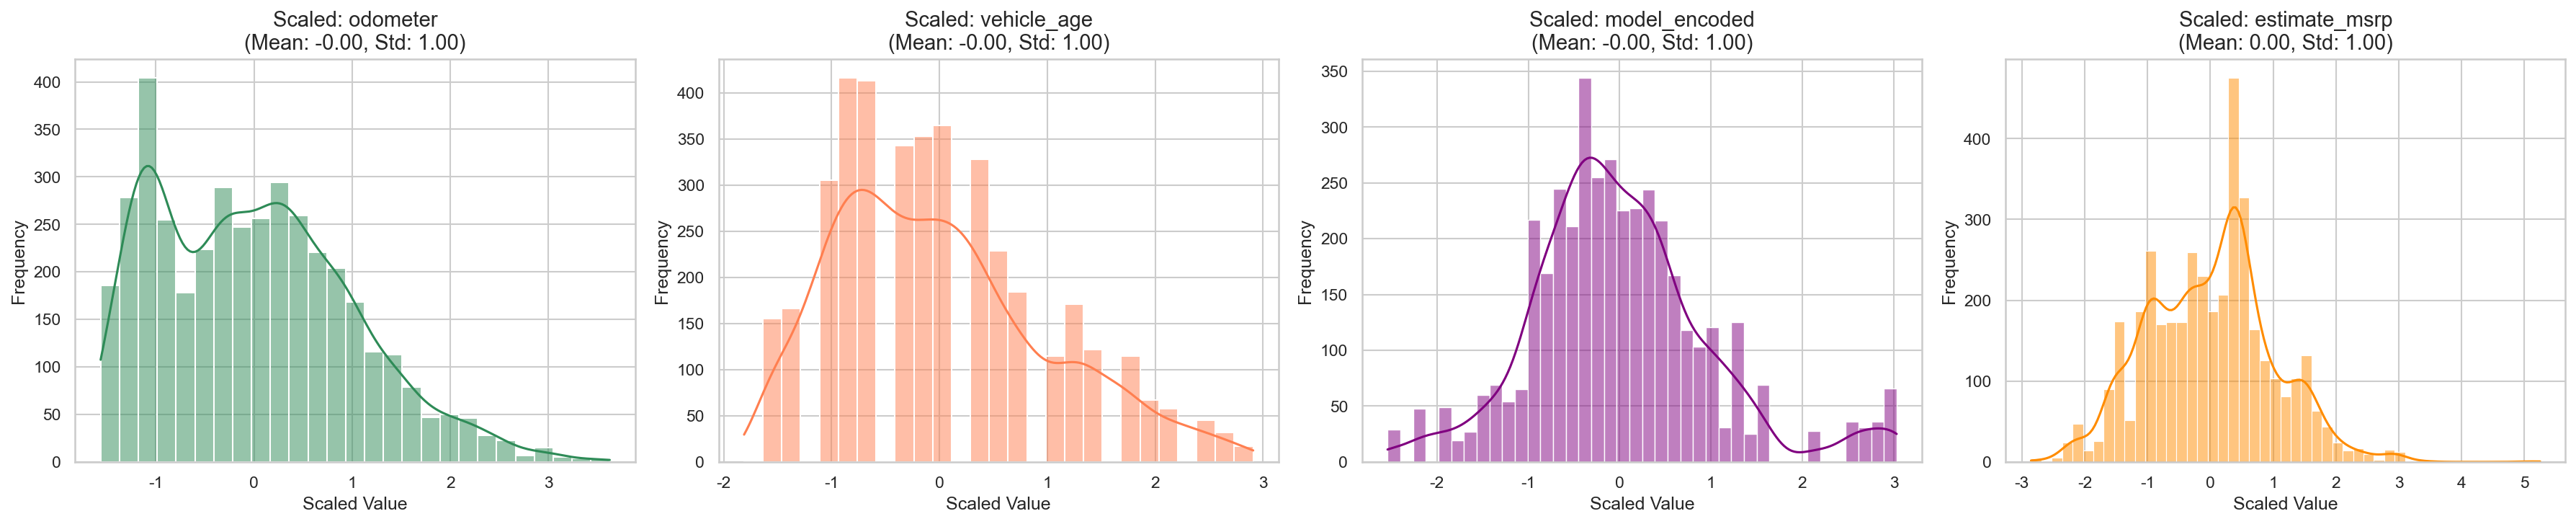

In [ ]:
# 2. 스케일링된 수치형 변수 분포 검증
# -> 평균이 0, 표준편차가 1 근처로 잘 모였는지 확인

scaled_cols = ['odometer', 'vehicle_age', 'model_encoded', 'estimate_msrp']

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
colors = ['seagreen', 'coral', 'purple', 'darkorange']

for i, col in enumerate(scaled_cols):
    sns.histplot(df_eda[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f"Scaled: {col}\n(Mean: {df_eda[col].mean():.2f}, Std: {df_eda[col].std():.2f})", fontsize=14)
    axes[i].set_xlabel("Scaled Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Scaled odometer, vehicle_age, model_encoded, estimate_msrp 그래프 해석

**기대 이유(효과)**  

각 feature별 값의 범위가 다름 → 특정 feature의 영향이 지나치게 커지거나 학습 속도가 느려질 수 있음 → Standard Scaling 적용.

LLM이 추정한 차량 출고가(MSRP)는 고가 차량이 일부 포함되어 우측 꼬리가 긴 형태(right-skewed)로 분포함.

StandardScaler만으로는 분포 형태 자체를 바꾸지 못하므로, 먼저 `np.log1p`로 로그 변환하여 정규분포에 가까운 형태로 만든 뒤 스케일링을 적용함.

---

**결과 해석**  

모든 그래프가 목표한 대로 변환 후 평균은 0, 표준편차는 1에 가까운 값을 보임.

**- odometer**  
일부 고주행 차량(이상치 여부는 추가 확인 필요)으로 인해 오른쪽 꼬리가 긴 형태를 보이지만, 전체적으로 안정적인 분포로 정규화되었음.

**- vehicle_age**  
연식이 정수값(이산형 변수)이므로 중간중간 비는 값이 존재함.  
비교적 부드러운 종 모양을 가지지만 오른쪽 꼬리가 약간 존재함 → 오래된 차량 일부가 포함되어 있음을 의미.

**- model_encoded**  
model_encoded는 Target Encoding을 적용한 변수임.  
각 차량 모델이 평균 가격 기반의 연속적인 값으로 변환되었기 때문에 scaling 이후 세 변수 중 정규분포에 가장 가까운 형태를 나타냄.

**- estimate_msrp**
중간값 부근에서 두 개의 봉우리가 관찰되며 이는 저가·고가 차량 그룹이 어느 정도 나뉘어져 있을 가능성을 시사함.

## 3. Target Encoding의 위력 확인 - 회귀선 산점도

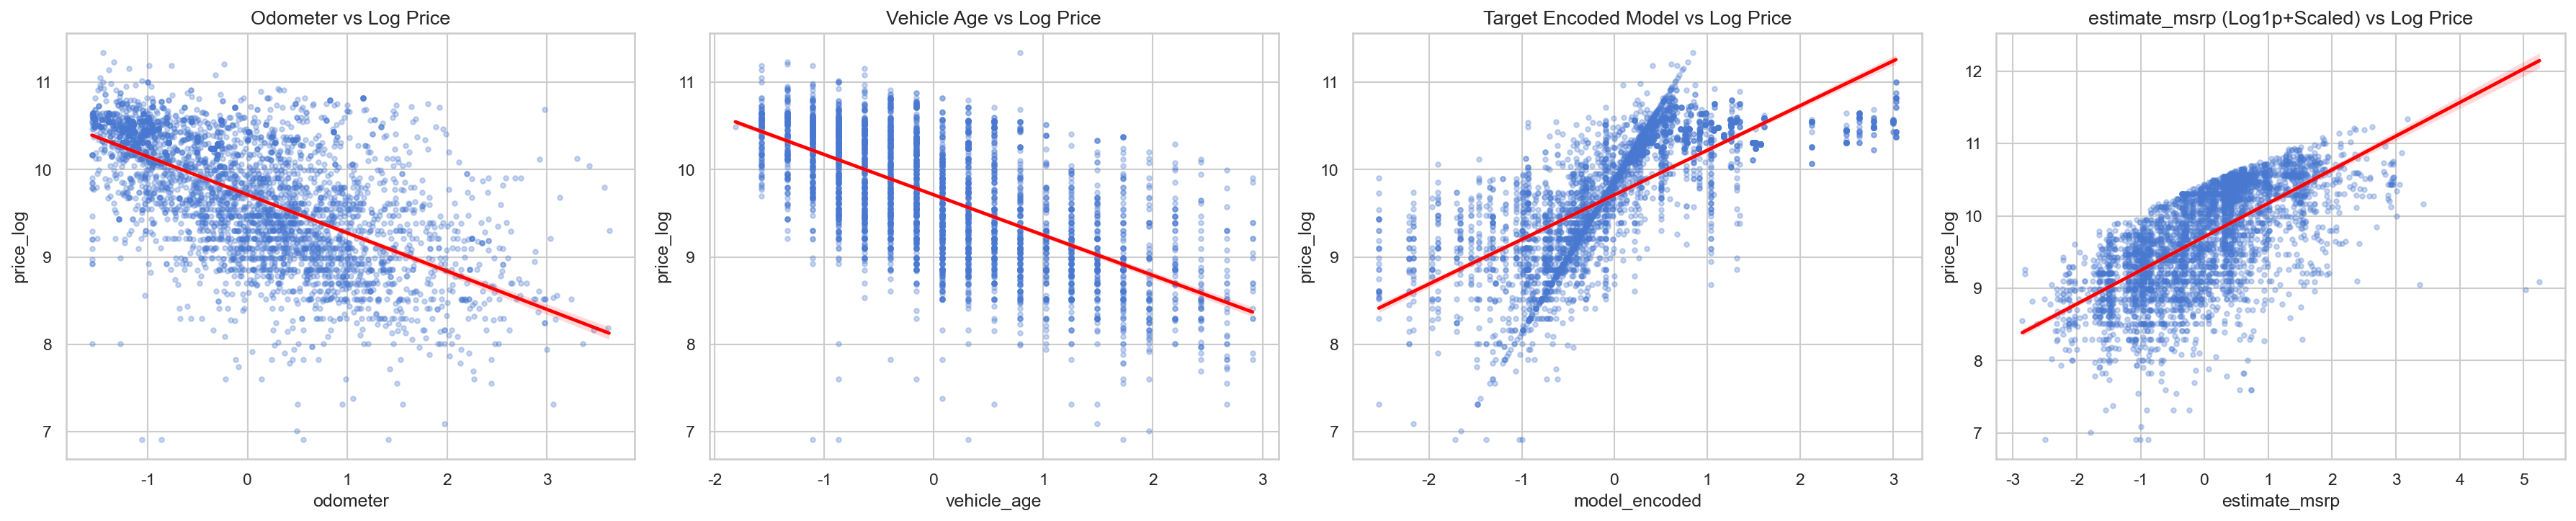

In [ ]:
# 3. 주요 수치형/인코딩 변수와 가격(Log)의 관계

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 3-1. 주행거리 vs 가격 (음의 상관관계 기대)
sns.regplot(data=df_eda, x='odometer', y='price_log', ax=axes[0],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[0].set_title("Odometer vs Log Price", fontsize=14)

# 3-2. 차량 나이 vs 가격 (음의 상관관계 기대)
sns.regplot(data=df_eda, x='vehicle_age', y='price_log', ax=axes[1],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[1].set_title("Vehicle Age vs Log Price", fontsize=14)

# 3-3. 모델 인코딩 값 vs 가격 (강한 양의 상관관계 기대!)
sns.regplot(data=df_eda, x='model_encoded', y='price_log', ax=axes[2],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[2].set_title("Target Encoded Model vs Log Price", fontsize=14)

# 3-4. 출고가 추정치 vs 가격 (양의 상관관계 기대)
sns.regplot(data=df_eda, x='estimate_msrp', y='price_log', ax=axes[3],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[3].set_title("estimate_msrp (Log1p+Scaled) vs Log Price", fontsize=14)

plt.tight_layout()
plt.show()

#### Scatter plot 그래프 해석

**기대 이유(효과)**  

feature와 가격 간 관계 확인, 선형 관계 존재 여부 확인, 회귀 모델에 유의미한 변수인지 검증을 위함.  
regression line(빨간 선)을 통해 양의 상관관계(+)인지 음의 상관관계(-)인지, 관계 강도를 시각적으로 확인 가능함.

---

**결과 해석**

**- odometer vs log price**  
회귀선을 통해 음의 상관관계 가짐을 알 수 있음 → 현실적인 패턴(주행거리가 길수록 가격이 떨어짐)을 따름.  
브랜드, 연식 등에 따라 가격에 영향을 받을 수 있기 때문에 완벽한 직선은 아님.

**- vehicle_age vs log price**  
역시 회귀선을 통해 음의 상관관계 가짐을 알 수 있음 → 현실적인 패턴(연식이 오래될수록 가격이 떨어짐)을 따름. 
vehicle_age는 정수값(이산형 변수)이므로 점이 세로로 나타남.

**- target encoded model vs log price**  
회귀선을 통해 양의 상관관계를 가짐을 알 수 있음.
model을 가격 기준으로 target encoding 했기 때문에 가격과 양의 상관관계를 가짐.

다만, 회귀선은 모든 점에 대한 최적의 직선을 찾기 때문에 중앙의 점들이 급상승하는 듯이 보이는 부분과는 차이가 있어 보일 수 있음.

**- estimate_msrp**  
로그 변환으로 x축 분포가 고르게 펼쳐지면서 양의 상관관계(+)가 더 선명하게 드러남.  
LLM이 차량 스펙 기반으로 추정한 출고가가 실제 중고가와 유의미한 관계를 가짐을 시각적으로 확인 가능함

## 4. 모델을 위한 핵심 상관관계 히트맵 - Top 15 피처

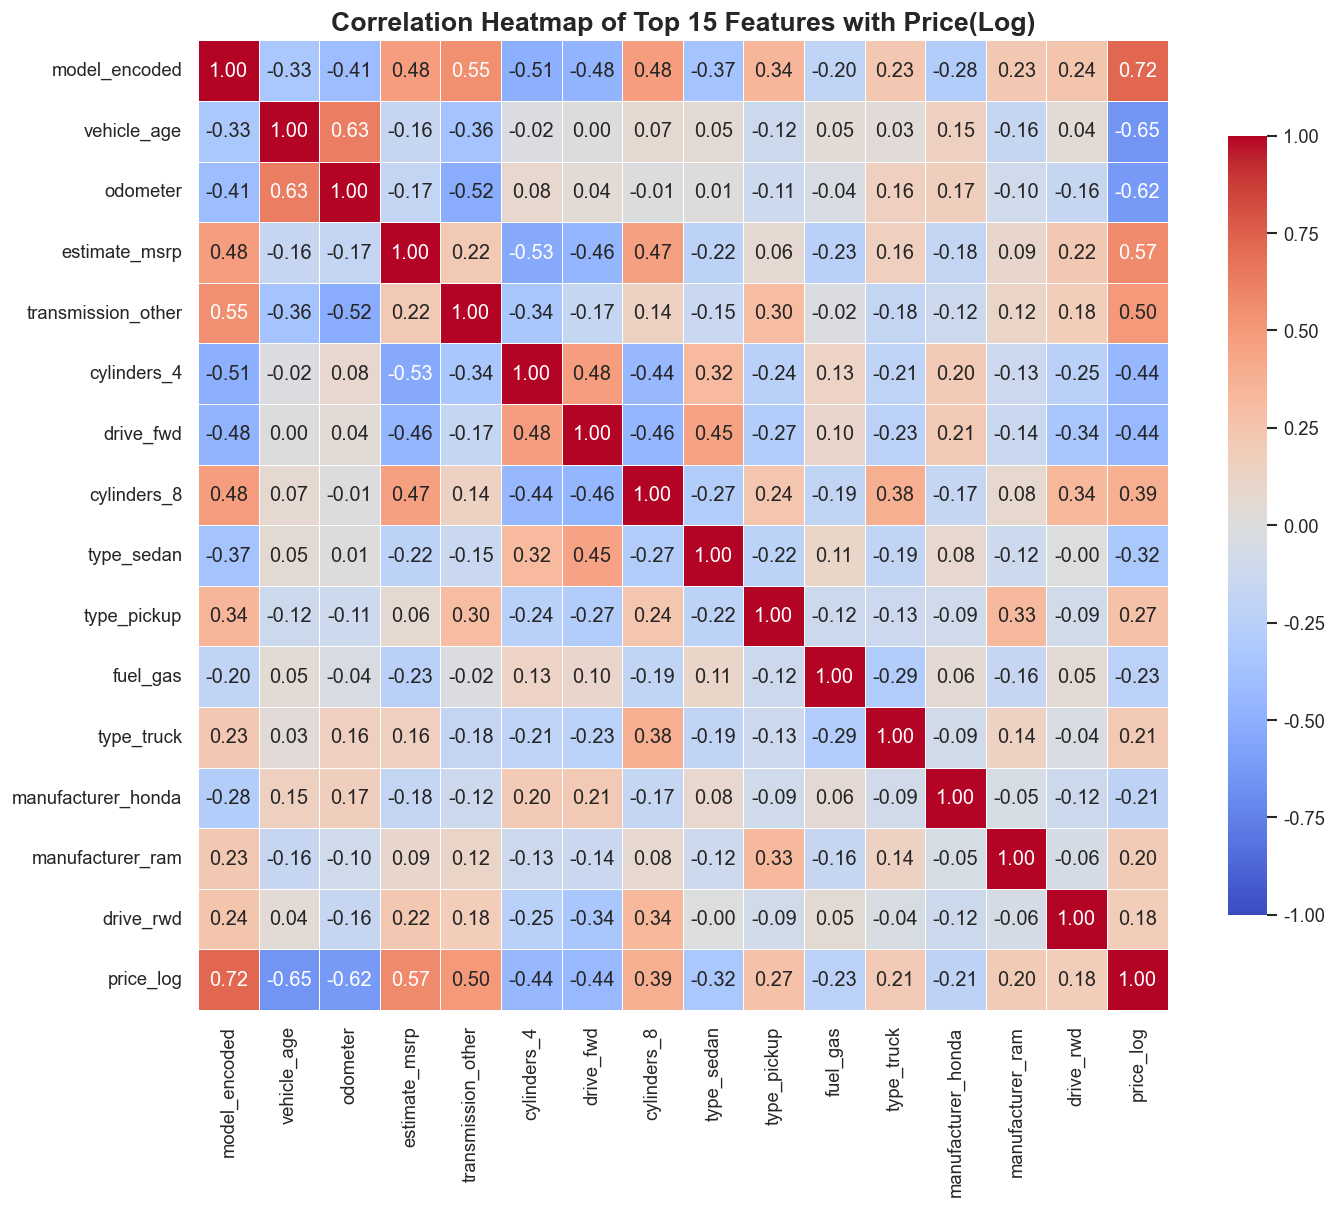

In [1]:
# 4. 타겟(price_log)과 가장 상관관계가 높은 Top 15 피처 추출 및 히트맵

# 타겟 변수와의 상관계수 계산 (절댓값 기준 내림차순)
correlations = df_eda.corr()['price_log'].abs().sort_values(ascending=False)

# 자기 자신(price_log)을 제외한 Top 15 피처 선정
top_15_features = correlations.index[1:16]

# Top 15 피처 + 타겟 변수로 상관관계 행렬 생성
top_corr_matrix = df_eda[top_15_features.tolist() + ['price_log']].corr()

plt.figure(figsize=(12, 10))
# 시각화
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Correlation Heatmap of Top 15 Features with Price(Log)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()